In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy import stats
import calpgs
import warnings
import seaborn as sns

import pandas as pd
from pandas.errors import SettingWithCopyWarning
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)


import matplotlib as mpl

mpl.rcParams['font.family'] = "Nimbus Sans"
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['font.size'] = 16

In [18]:
!rm sim_df_PGS*

In [6]:
if True:

    alldr2s = []

    for delta in range(0,21):
        delta = delta*5
        deltar2 = []
        
    
        for i in range(30):
            
            df = pd.read_csv(f"sim_df_PGS.h20.5.causal1.gamma{delta}.seed{i}.tsv",sep="\t")
            col =  "quant"
           
            col_q = pd.qcut(df[col], q=10).cat.codes
            df[f"{col}_q"] = col_q
            #df["yadj"] = sm.OLS(df["y"],df[["quant"]]).fit().resid
            df["yadj"] = df["y"]
            df = df.iloc[-10000:]
            top = df[df["quant_q"]==9]
            bot = df[df["quant_q"]==0]
            for j in range(5):
                deltar2.append((stats.spearmanr(top[f"PGS_{j}"],top["yadj"])[0]**2-stats.spearmanr(bot[f"PGS_{j}"],bot["yadj"])[0]**2)/stats.spearmanr(df[f"PGS_{j}"],df["yadj"])[0]**2)
        print(delta,np.mean(deltar2))
        alldr2s.append(np.mean(deltar2))
    df = pd.DataFrame([np.arange(0,21),alldr2s]).T
    df[0] = df[0].astype(int)
    df[1] = df[1].abs()*100
    df.to_csv("f2_deltaR2.tsv",sep="\t",header=None,index=None)

0 0.027395890680614366
5 -0.062029412985858956
10 -0.15170424220641074
15 -0.2408857878152192
20 -0.3294396726908194
25 -0.4180452267676852
30 -0.5058343892129238
35 -0.5924961749371547
40 -0.6787598789101986
45 -0.7641673917650574
50 -0.8485766935626666
55 -0.9318133669617221
60 -1.0134973157110103
65 -1.0943993592053582
70 -1.1732612194515422
75 -1.2508971873043329
80 -1.3269980238873704
85 -1.4022807464317293
90 -1.4752246087960483
95 -1.547772423615122
100 -1.6197253158835265


<>:98: SyntaxWarning: invalid escape sequence '\D'
<>:98: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1239452/3237132032.py:98: SyntaxWarning: invalid escape sequence '\D'
  ax.set_xlabel("$\Delta R^2$")
/tmp/ipykernel_1239452/3237132032.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())


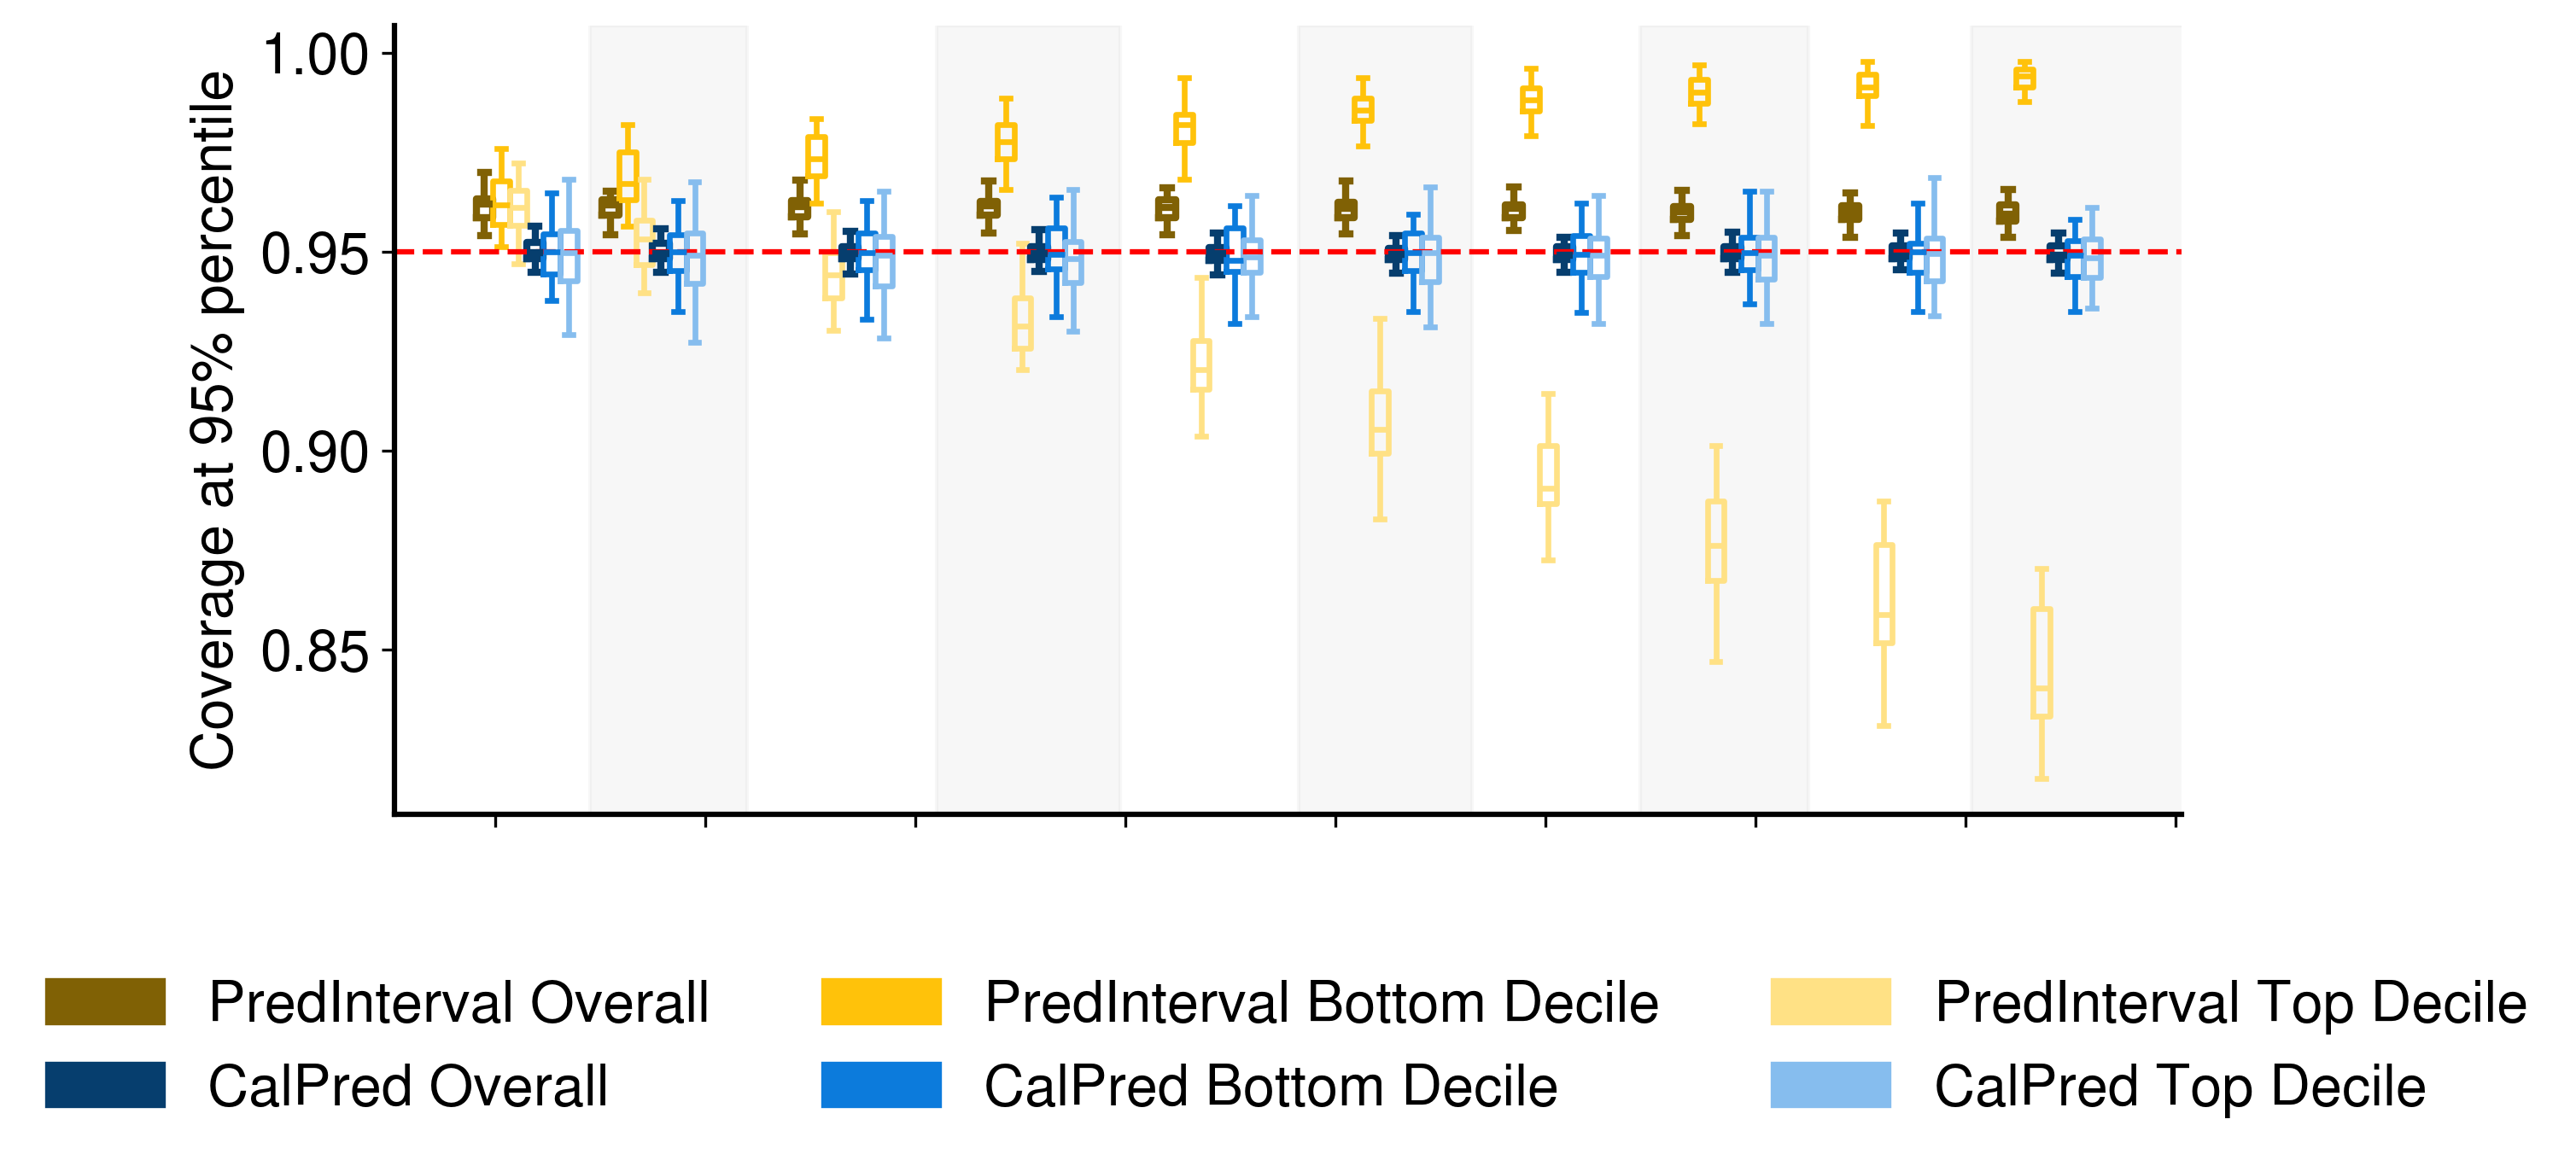

In [10]:
results = []

xmap = pd.read_csv("f2_deltaR2.tsv",sep="\t",header=None)
xmap = dict(zip(xmap[0],xmap[1]))

for i in range(21):
    gamma = i
    if i%2==1:
        continue
    df = pd.read_csv(f"calPred.gamma{i*5}.h20.5.causal1.alpha95.decile.stats.tsv", sep="\t").rename(
        columns={"adjust": "method"}
    )
    df = pd.concat([df,pd.read_csv(f"PredInterval.gamma{i*5}.h20.5.causal1.alpha95.decile.stats.tsv", sep="\t").rename(columns={"adjust": "method"})])
    
    
    df["method"] = df["method"].apply(
        lambda x: {"PredInterval":"PredInterval","all": "CalPred"}[x]
    )

    
    
    value = "coverage"
    for method in ["PredInterval","CalPred"]:

        for quantile in ["marginal","quant_q_0","quant_q_9"]:

            data = df[(df.col==quantile) & (df.method==method)][value].values
            for i in range(len(data)):
                results.append([xmap[gamma],f"{method}_{quantile}",i,data[i]])
    
            
results = pd.DataFrame(results)
results.columns=[0,"Method","seed",value]
results[0] = results[0].round()


results = results[results[0]<150]



colors = {
    "PredInterval Overall":"#806105",
    "PredInterval Top Decile":"#ffe185",
    "PredInterval Bottom Decile":"#ffc20a",
    "CalPred Overall":"#063e6e",
    "CalPred Top Decile":"#86bdee",
    "CalPred Bottom Decile":"#0c7bdc",
}
results.replace({"CalPred_marginal":"CalPred Overall","PredInterval_marginal":"PredInterval Overall","PredInterval_quant_q_0":"PredInterval Bottom Decile","PredInterval_quant_q_9":"PredInterval Top Decile","CalPred_quant_q_9":"CalPred Top Decile","CalPred_quant_q_0":"CalPred Bottom Decile"},inplace=True)
fig,ax = plt.subplots(figsize=(9,4),dpi=300)
legend = 1
if legend==False:
    sns.boxplot(results,x=0,y=value,hue="Method",ax=ax,palette=colors,saturation=1,showfliers=False,native_scale=True,fill=0,linewidth=2,legend=0,width=0.45)
else:
    sns.boxplot(results,x=0,y=value,hue="Method",ax=ax,palette=colors,saturation=1,showfliers=False,native_scale=True,fill=0,linewidth=2)
    h,l = ax.get_legend_handles_labels()
    h = [h[x] for x in [0,3,1,4,2,5]]

    
    for i in h:
        i.set_fc(i.get_ec())
    
    ax.legend(h,[l[x] for x in [0,3,1,4,2,5]],loc="lower center",bbox_to_anchor=(0.5,-0.45),ncols=3,frameon=0)


boxes = [c for c in ax.get_children() if isinstance(c, mpl.lines.Line2D)]
for b in boxes:
    if b.get_c()=="#806105" or b.get_c()=="#063e6e":
        b.set_linewidth(2)
    else:
        b.set_linewidth(1.6)


xlim = ax.get_xlim()

xs = results[0].unique()
for i in range(len(xs)):
    if i%2==0:
        continue
    prevx = xs[i-1]
    x = xs[i]
    try:
        nextx = xs[i+1]
    except:
        nextx = 200

    ax.axvspan((x + prevx)/2, (x + nextx)/2, color="grey", alpha=0.06, zorder=0)
ax.set_xlim(xlim)
        
if value=="coverage":
    ax.axhline(0.95,linestyle="--",color="red")
    ax.set_ylabel("Coverage at 95% percentile")
    ax.set_xlabel("")
    ax.set_xticklabels([])

else:
    ax.set_ylabel("Prediction s.d.")
    ax.set_xlabel("$\Delta R^2$")
    ax.set_xticklabels(ax.get_xticklabels())
ax.set_yticklabels(ax.get_yticklabels())
ax.spines[['right', 'top']].set_visible(False)
if legend==False:
    plt.savefig("fig2_realPGS_gammacoverage95.png",bbox_inches='tight')
else:
    #plt.savefig("figures/fig2_gammalength_nolegend.png",bbox_inches='tight')
    plt.savefig("fig2_realPGS_legend.png",bbox_inches='tight')

/tmp/ipykernel_1239452/2093450552.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_1239452/2093450552.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())


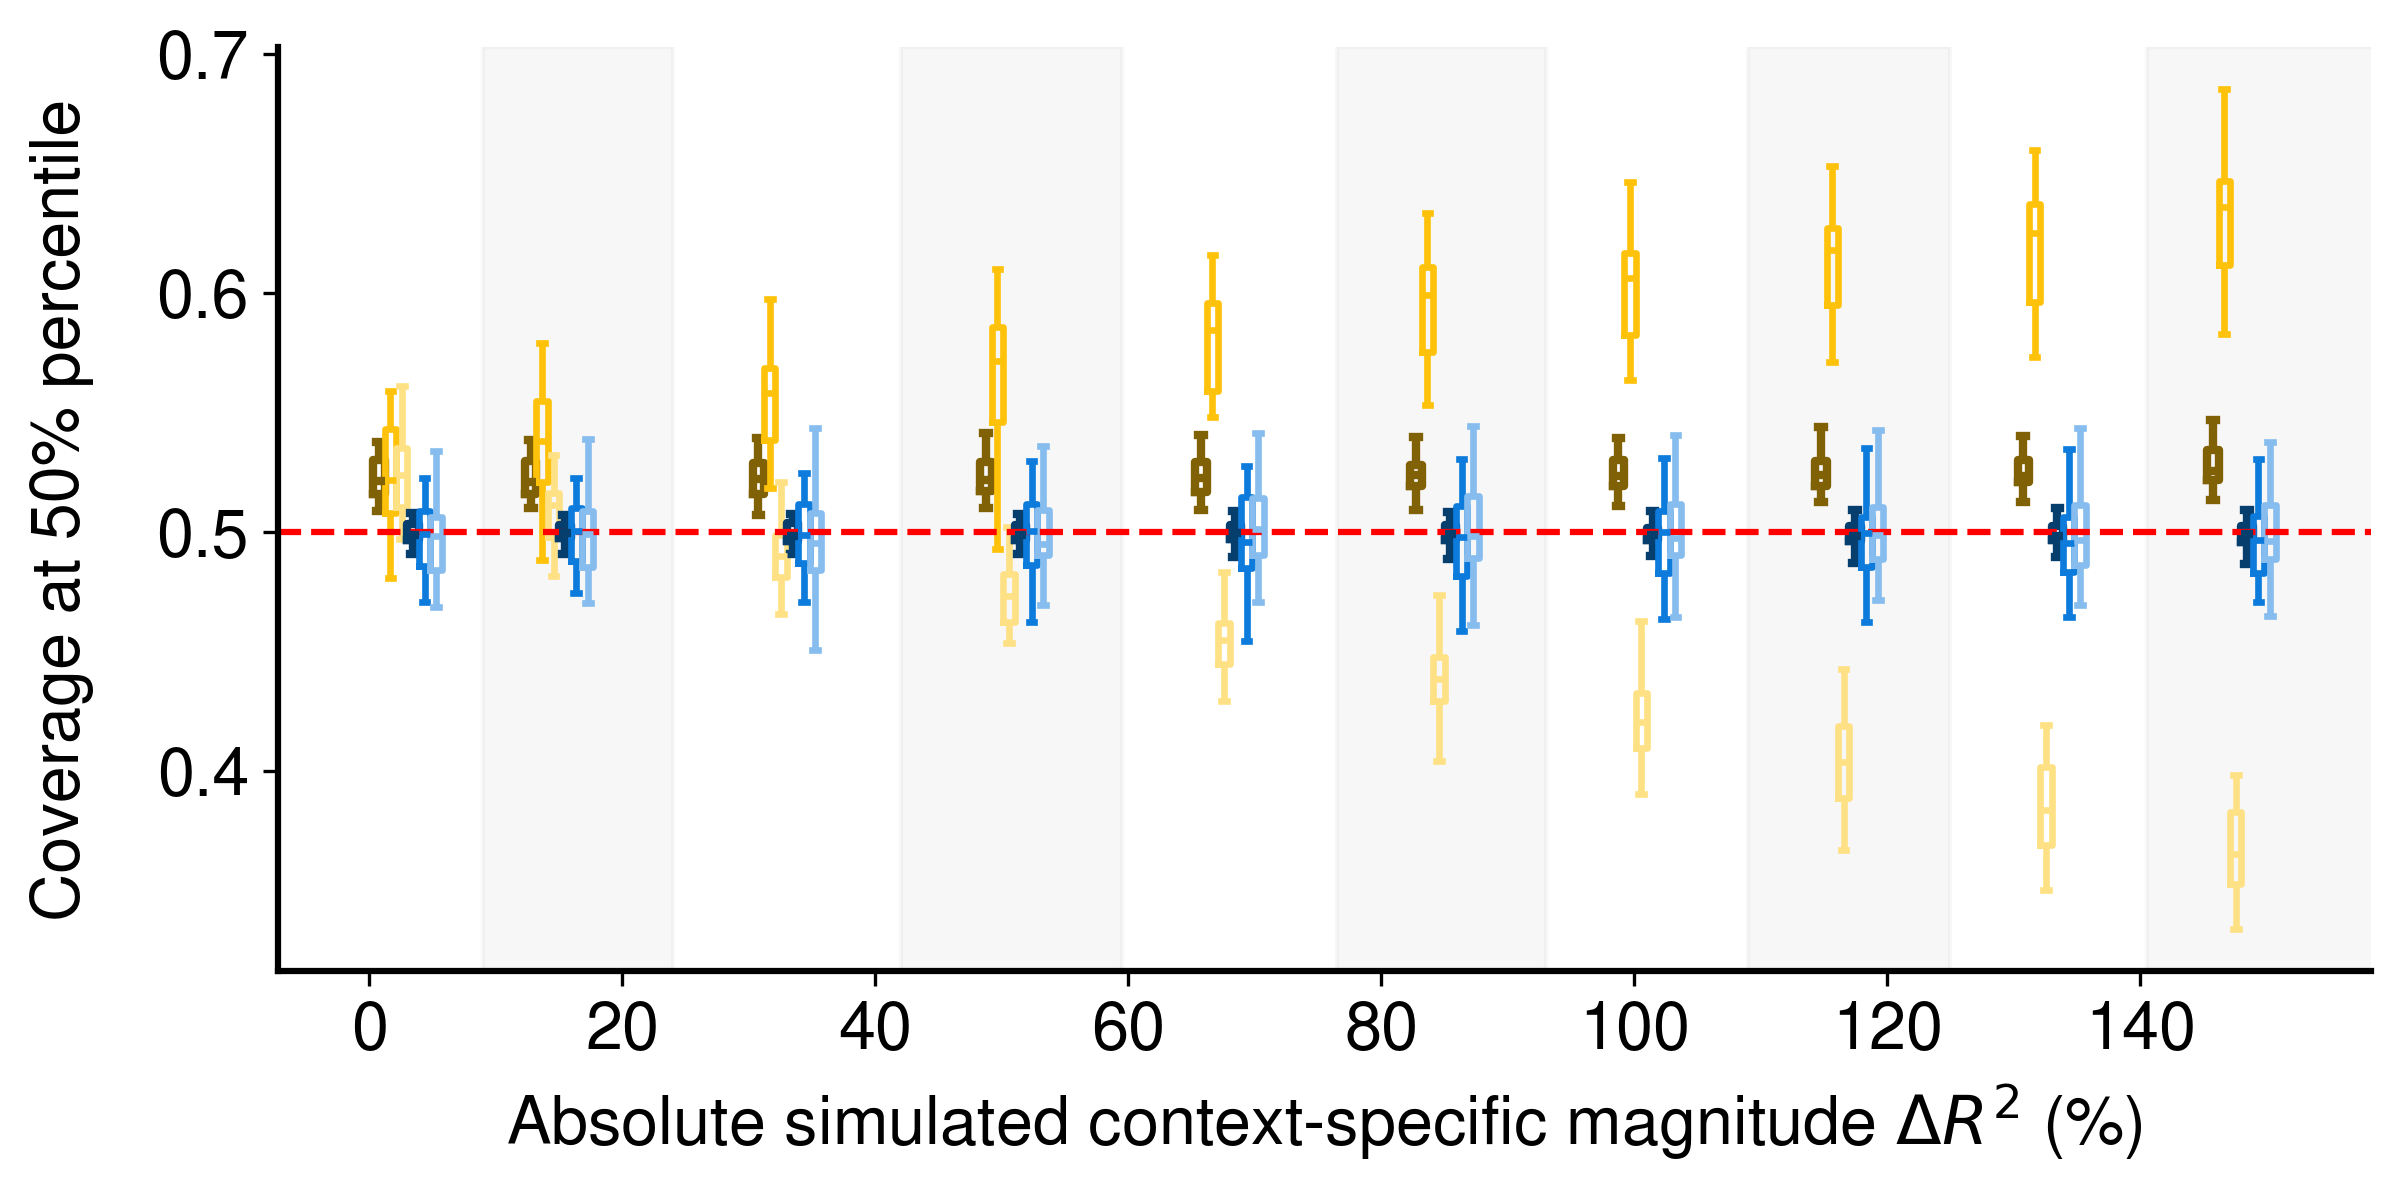

In [13]:
results = []
xmap = pd.read_csv("f2_deltaR2.tsv",sep="\t",header=None)
xmap = dict(zip(xmap[0],xmap[1]))

for i in range(21):
    gamma = i
    if i%2==1:
        continue
    df = pd.read_csv(f"calPred.gamma{i*5}.h20.5.causal1.alpha50.decile.stats.tsv", sep="\t").rename(
        columns={"adjust": "method"}
    )
    df = pd.concat([df,pd.read_csv(f"PredInterval.gamma{i*5}.h20.5.causal1.alpha50.decile.stats.tsv", sep="\t").rename(columns={"adjust": "method"})])
    
    
    df["method"] = df["method"].apply(
        lambda x: { "PredInterval":"PredInterval","all": "CalPred"}[x]
    )


    value = "coverage"
    for method in ["PredInterval","CalPred"]:

        for quantile in ["marginal","quant_q_0","quant_q_9"]:

            data = df[(df.col==quantile) & (df.method==method)][value].values
            for i in range(len(data)):
                results.append([xmap[gamma],f"{method}_{quantile}",i,data[i]])
                #results.append([x*100,f"{method}_{quantile}",i,data[i]])
            
results = pd.DataFrame(results)
results.columns=[0,"Method","seed",value]
results[0] = results[0].round()


results = results[results[0]<150]



colors = {
    "PredInterval Overall":"#806105",
    "PredInterval Top Decile":"#ffe185",
    "PredInterval Bottom Decile":"#ffc20a",
    "CalPred Overall":"#063e6e",
    "CalPred Top Decile":"#86bdee",
    "CalPred Bottom Decile":"#0c7bdc",

}
results.replace({"CalPred_marginal":"CalPred Overall","PredInterval_marginal":"PredInterval Overall","PredInterval_quant_q_0":"PredInterval Bottom Decile","PredInterval_quant_q_9":"PredInterval Top Decile","CalPred_quant_q_9":"CalPred Top Decile","CalPred_quant_q_0":"CalPred Bottom Decile"},inplace=True)
fig,ax = plt.subplots(figsize=(9,4),dpi=300)
if value=="coverage":
#if value=="coverage" or value=="length":
    sns.boxplot(results,x=0,y=value,hue="Method",ax=ax,palette=colors,saturation=1,showfliers=False,native_scale=True,fill=0,linewidth=2,legend=0,width=0.45)
else:
    sns.boxplot(results,x=0,y=value,hue="Method",ax=ax,palette=colors,saturation=1,showfliers=False,native_scale=True,fill=0,linewidth=2)
    h,l = ax.get_legend_handles_labels()
    h = [h[x] for x in [0,3,1,4,2,5]]
    for i in h:
        i.set_fc(i.get_ec())
    ax.legend(h,[l[x] for x in [0,3,1,4,2,5]],loc="lower center",bbox_to_anchor=(0.5,-0.45),ncols=3,frameon=0)
#ax.scatter(ax.get_children()[0].get_xydata()[:,0],ax.get_children()[0].get_xydata()[:,1],marker="o",s=10)

boxes = [c for c in ax.get_children() if isinstance(c, mpl.lines.Line2D)]
for b in boxes:
    if b.get_c()=="#806105" or b.get_c()=="#063e6e":
        b.set_linewidth(2)
    else:
        b.set_linewidth(1.6)


xlim = ax.get_xlim()

xs = results[0].unique()
for i in range(len(xs)):
    if i%2==0:
        continue
    prevx = xs[i-1]
    x = xs[i]
    try:
        nextx = xs[i+1]
    except:
        nextx = 200

    ax.axvspan((x + prevx)/2, (x + nextx)/2, color="grey", alpha=0.06, zorder=0)
ax.set_xlim(xlim)    

if value=="coverage":
    ax.axhline(0.5,linestyle="--",color="red")
    ax.set_ylabel("Coverage at 50% percentile",labelpad=15)
    ax.set_xlabel("Absolute simulated context-specific magnitude $\\Delta R^2$ (%)")

    ax.set_xticklabels(ax.get_xticklabels())

ax.set_yticklabels(ax.get_yticklabels())
ax.spines[['right', 'top']].set_visible(False)

plt.savefig("fig2_realPGS_gammacoverage50.png",bbox_inches='tight')


/tmp/ipykernel_1239452/3575216533.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_1239452/3575216533.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels())


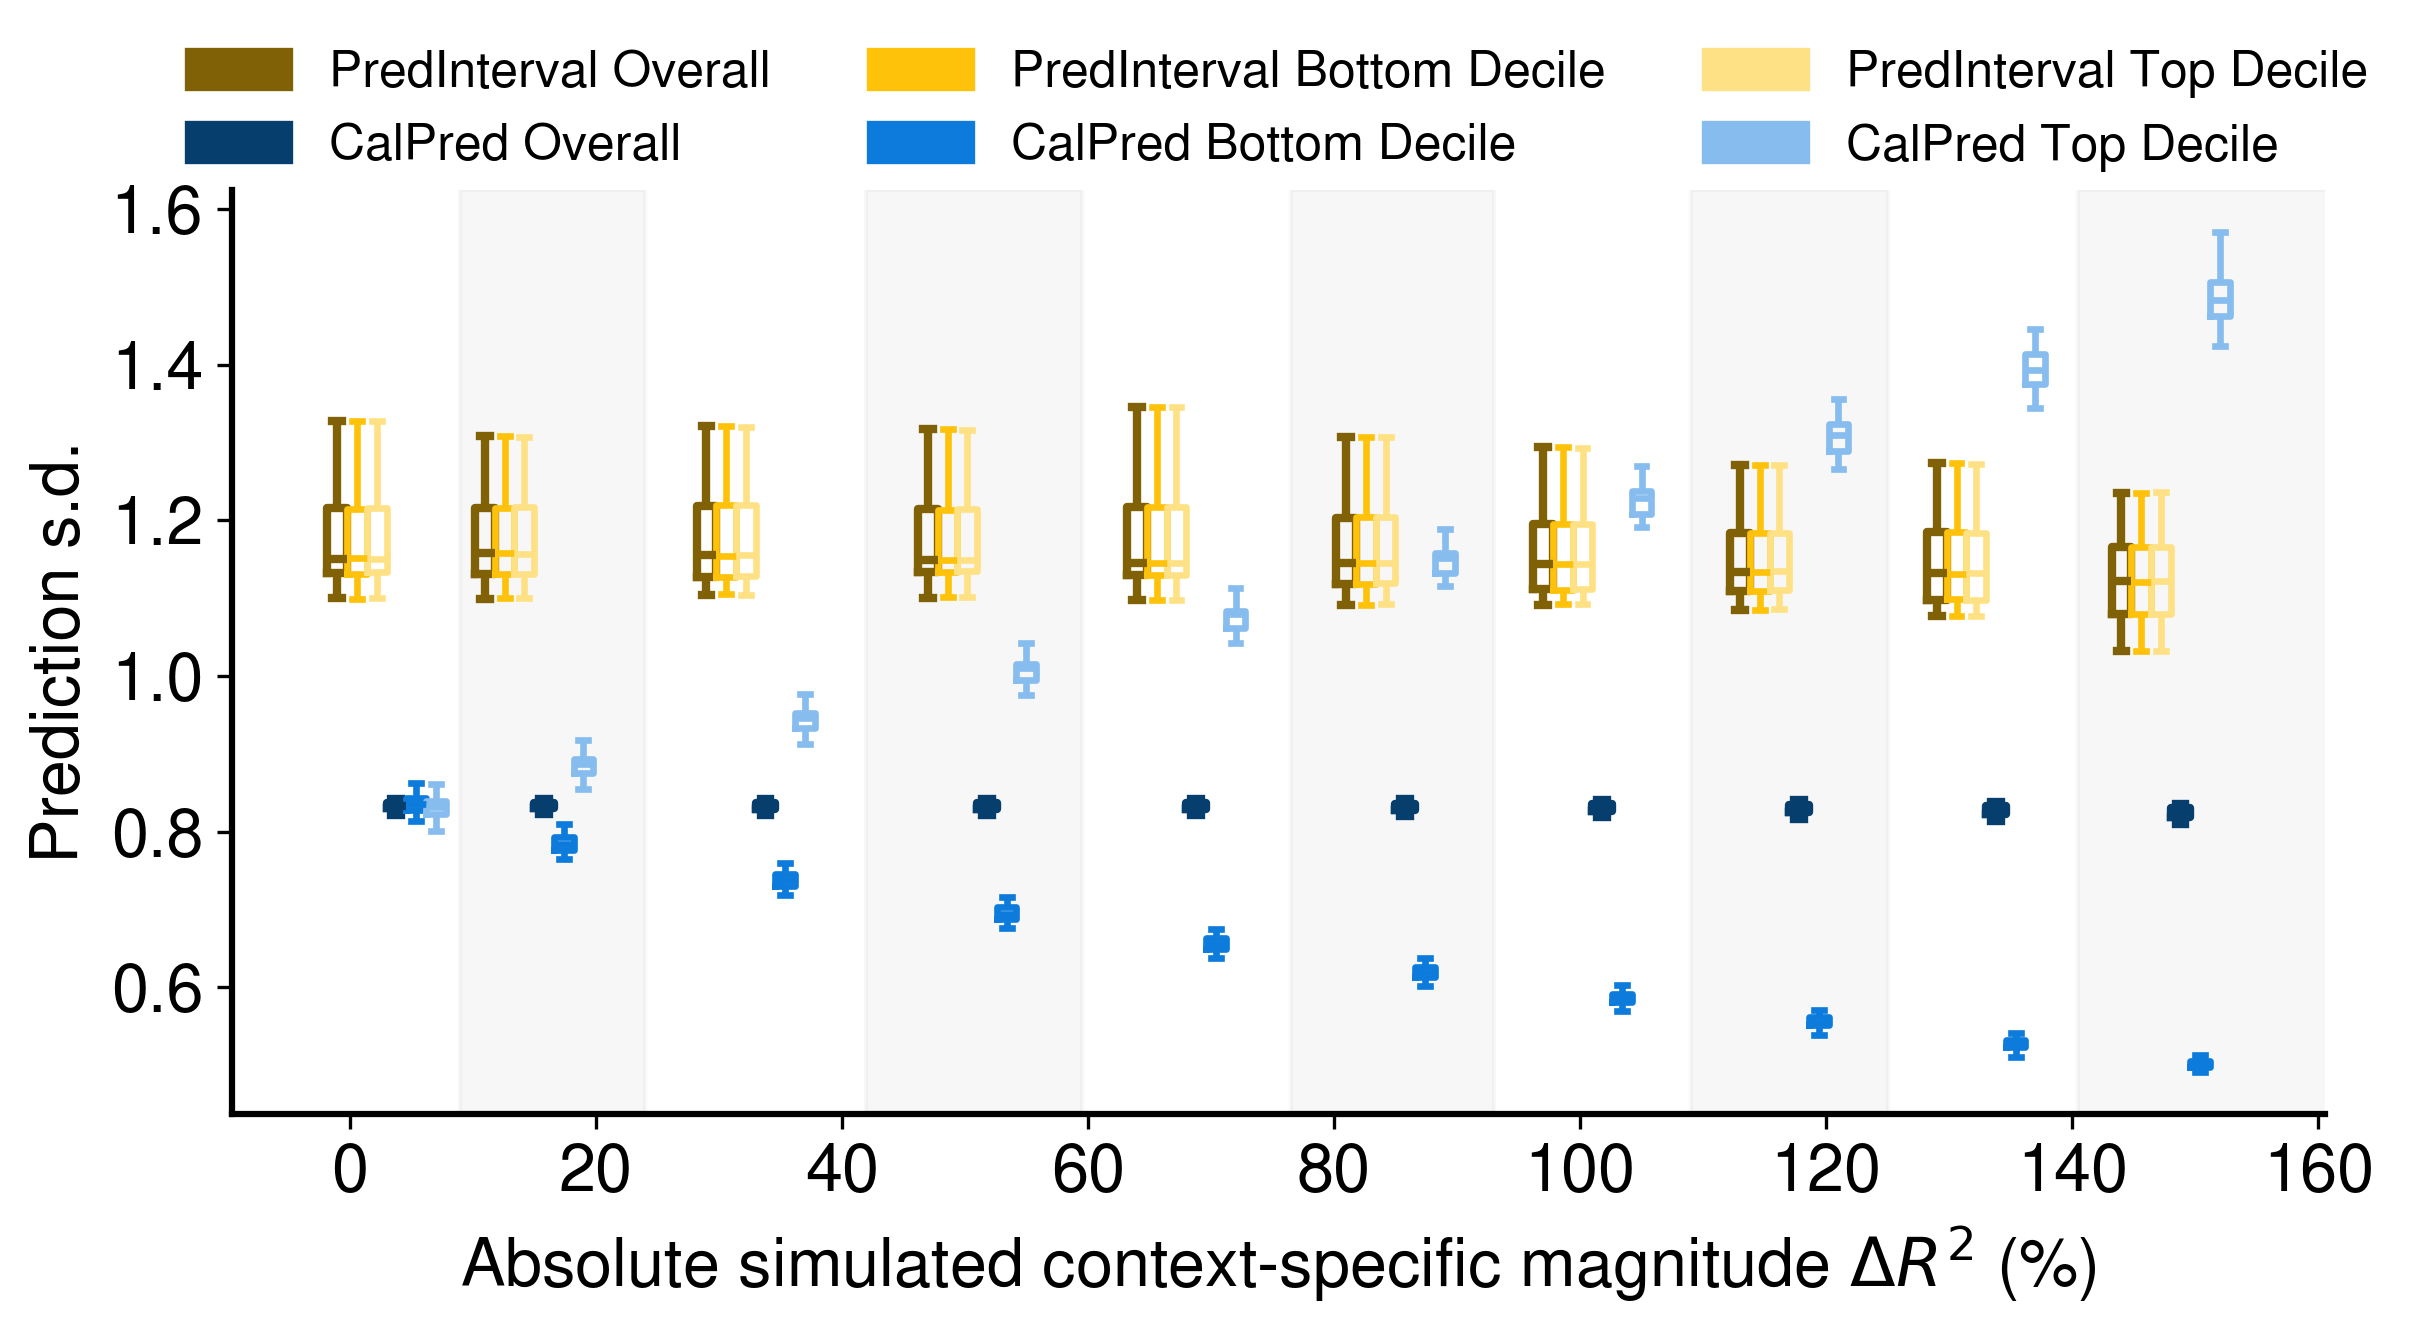

In [15]:
results = []
xmap = pd.read_csv("f2_deltaR2.tsv",sep="\t",header=None)
xmap = dict(zip(xmap[0],xmap[1]))

for i in range(21):
    gamma = i
    if i%2==1:
        continue
    df = pd.read_csv(f"calPred.gamma{i*5}.h20.5.causal1.alpha50.decile.stats.tsv", sep="\t").rename(
        columns={"adjust": "method"}
    )
    df = pd.concat([df,pd.read_csv(f"PredInterval.gamma{i*5}.h20.5.causal1.alpha50.decile.stats.tsv", sep="\t").rename(columns={"adjust": "method"})])
    
    
    df["method"] = df["method"].apply(
        lambda x: { "PredInterval":"PredInterval","all": "CalPred"}[x]
    )

        
    value = "length"
    for method in ["PredInterval","CalPred"]:

        for quantile in ["marginal","quant_q_0","quant_q_9"]:

            data = df[(df.col==quantile) & (df.method==method)][value].values
            for i in range(len(data)):
                results.append([xmap[gamma],f"{method}_{quantile}",i,data[i]])
                #results.append([x*100,f"{method}_{quantile}",i,data[i]])
            
results = pd.DataFrame(results)
results.columns=[0,"Method","seed",value]
results[0] = results[0].round()


results = results[results[0]<150]



colors = {
    "PredInterval Overall":"#806105",
    "PredInterval Top Decile":"#ffe185",
    "PredInterval Bottom Decile":"#ffc20a",
    "CalPred Overall":"#063e6e",
    "CalPred Top Decile":"#86bdee",
    "CalPred Bottom Decile":"#0c7bdc",

}
results.replace({"CalPred_marginal":"CalPred Overall","PredInterval_marginal":"PredInterval Overall","PredInterval_quant_q_0":"PredInterval Bottom Decile","PredInterval_quant_q_9":"PredInterval Top Decile","CalPred_quant_q_9":"CalPred Top Decile","CalPred_quant_q_0":"CalPred Bottom Decile"},inplace=True)
fig,ax = plt.subplots(figsize=(9,4),dpi=300)
sns.boxplot(results,x=0,y=value,hue="Method",ax=ax,palette=colors,saturation=1,showfliers=False,native_scale=True,fill=0,linewidth=2)
h,l = ax.get_legend_handles_labels()
h = [h[x] for x in [0,3,1,4,2,5]]
for i in h:
    i.set_fc(i.get_ec())
ax.legend(h,[l[x] for x in [0,3,1,4,2,5]],loc="upper center",bbox_to_anchor=(0.5,1.2),ncols=3,frameon=0,fontsize=12)


boxes = [c for c in ax.get_children() if isinstance(c, mpl.lines.Line2D)]
for b in boxes:
    if b.get_c()=="#806105" or b.get_c()=="#063e6e":
        b.set_linewidth(2)
    else:
        b.set_linewidth(1.6)


xlim = ax.get_xlim()

xs = results[0].unique()
for i in range(len(xs)):
    if i%2==0:
        continue
    prevx = xs[i-1]
    x = xs[i]
    try:
        nextx = xs[i+1]
    except:
        nextx = 200

    ax.axvspan((x + prevx)/2, (x + nextx)/2, color="grey", alpha=0.06, zorder=0)
ax.set_xlim(xlim)        

ax.set_ylabel("Prediction s.d.")
ax.set_xlabel("Absolute simulated context-specific magnitude $\\Delta R^2$ (%)")

ax.set_xticklabels(ax.get_xticklabels())

ax.set_yticklabels(ax.get_yticklabels())
ax.spines[['right', 'top']].set_visible(False)

plt.savefig("fig2_realPGS_length.png",bbox_inches='tight')
